# 00 EDA — Total Time Analysis

**total_time_min** = wait_call_min + prepare_loading_min + loading_time_min + close_job_min

แทนเวลาทั้งหมดที่รถใช้ตั้งแต่ OperatorCarConfirm ถึง PostingTime

**Sections**
1. Load Data
2. Distribution Analysis
3. Phase Breakdown
4. Segment — CarType
5. Segment — PickListType
6. Segment — PrepareForward
7. Segment — PostLocationName
8. Time Patterns (Hour / Month / WeekOfMonth)
9. Truck Sequence Effect
10. Product & SAP Analysis
11. Average Time by CarType Features
12. Correlation Analysis
13. Business Insights Summary

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from scipy import stats as scipy_stats

DATA_PATH  = Path('../../data/interim/vw_timestamp_dashboard_featured_no_outlier.csv')
FIGURE_DIR = Path('../../reports/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_theme(style='whitegrid', palette='muted')

DECODE = {
    'CarType'        : {0: '10 ล้อ', 1: '4 ล้อ', 2: '6 ล้อ', 3: 'เทรเลอร์'},
    'PickListType'   : {0: 'SmartQ', 1: 'Walk-in', 2: 'ล่วงหน้า'},
    'PrepareForward' : {0: 'N', 1: 'Y'},
}

print('Libraries loaded')

Libraries loaded


In [92]:
def grouped_boxplot(ax, df, x_col, y_col, order=None, palette='Set2',
                    rotation=0, tick_labels=None):
    """Colored matplotlib boxplot. Uses decode map for labels if available."""
    if order is None:
        order = sorted(df[x_col].dropna().unique().tolist())
    if len(order) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        return None
    groups = [df[df[x_col] == g][y_col].dropna().values for g in order]
    colors = sns.color_palette(palette, len(order))
    if tick_labels is None:
        dec = DECODE.get(x_col, {})
        tick_labels = [dec.get(g, str(g)) for g in order]
    bp = ax.boxplot(
        groups, tick_labels=tick_labels, patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
        boxprops=dict(linewidth=0.8),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        flierprops=dict(marker='.', markersize=4,
                        markerfacecolor='gray', markeredgecolor='gray', alpha=0.4),
    )
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    if rotation:
        ax.set_xticklabels(tick_labels, rotation=rotation, ha='right')
    return bp

print('Helper ready')

Helper ready


## 1. Load Data

In [93]:
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig', low_memory=False)

TARGET    = 'total_time_min'
SUB_TIMES = ['wait_call_min', 'prepare_loading_min', 'loading_time_min', 'close_job_min']
LABELS    = ['Wait Call', 'Prepare Loading', 'Loading', 'Close Job']
COLORS    = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

df = df[df[TARGET].notna()].copy()
available    = [c for c in SUB_TIMES if c in df.columns]
labels_avail = LABELS[:len(available)]
color_avail  = COLORS[:len(available)]

print(f'Shape  : {df.shape}')
print(f'Columns: {list(df.columns)}')

for col in ['CarType', 'PickListType', 'PrepareForward']:
    if col in df.columns:
        vals = sorted(df[col].dropna().unique().tolist())
        dec  = DECODE.get(col, {})
        print(f'{col}: {vals} -> {[dec.get(v, v) for v in vals]}')

Shape  : (22085, 68)
Columns: ['PlantName', 'PickListType', 'PickDate', 'TruckSeqNo', 'CarType', 'CarNo', 'PackListNo', 'CustomerName', 'QueueTime', 'PrepareForward', 'TruckReceiveDate', 'TruckReceiveHour', 'TruckReceiveMinute', 'CreateDate', 'PickingTime', 'OperatorCarConfirm', 'CarConfirm', 'PostingTime', 'FirstPostPallet', 'LastPostPallet', 'TruckStatus', 'PackListStatus', 'PostLocationName', 'CPACTileSapAmount', 'PRESTIGETileSapAmount', 'NEUSTILETileSapAmount', 'CPACFittingSapAmount', 'PRESTIGEFittingSapAmount', 'NEUSTILEFittingSapAmount', 'DURAFittingSapAmount', 'ACCESSORIESSapAmount', 'TileStart', 'TileEnd', 'FittingStart', 'FittingEnd', 'AccStart', 'AccEnd', 'total_time_min', 'hour', 'day_of_week', 'week_of_month', 'month', 'year', 'total_tile_amount', 'total_fitting_amount', 'total_accessories_amount', 'total_sap_amount', 'has_tile', 'has_fitting', 'has_accessories', 'product_group_count', 'wait_call_min', 'prepare_loading_min', 'loading_time_min', 'close_job_min', 'queue_waiti

In [94]:
from scipy import stats as scipy_stats

print('=== total_time_min Statistics ===')
stats = df[TARGET].describe(percentiles=[.05, .25, .5, .75, .90, .95])
for k, v in stats.items():
    print(f'  {k:>8s} : {v:>8.2f} min')
print(f'  {"skewness":>8s} : {scipy_stats.skew(df[TARGET]):>8.3f}')

=== total_time_min Statistics ===
     count : 22085.00 min
      mean :    54.63 min
       std :    21.57 min
       min :     5.43 min
        5% :    24.00 min
       25% :    38.62 min
       50% :    51.78 min
       75% :    67.83 min
       90% :    85.09 min
       95% :    96.32 min
       max :   120.00 min
  skewness :    0.576


## 2. Distribution Analysis

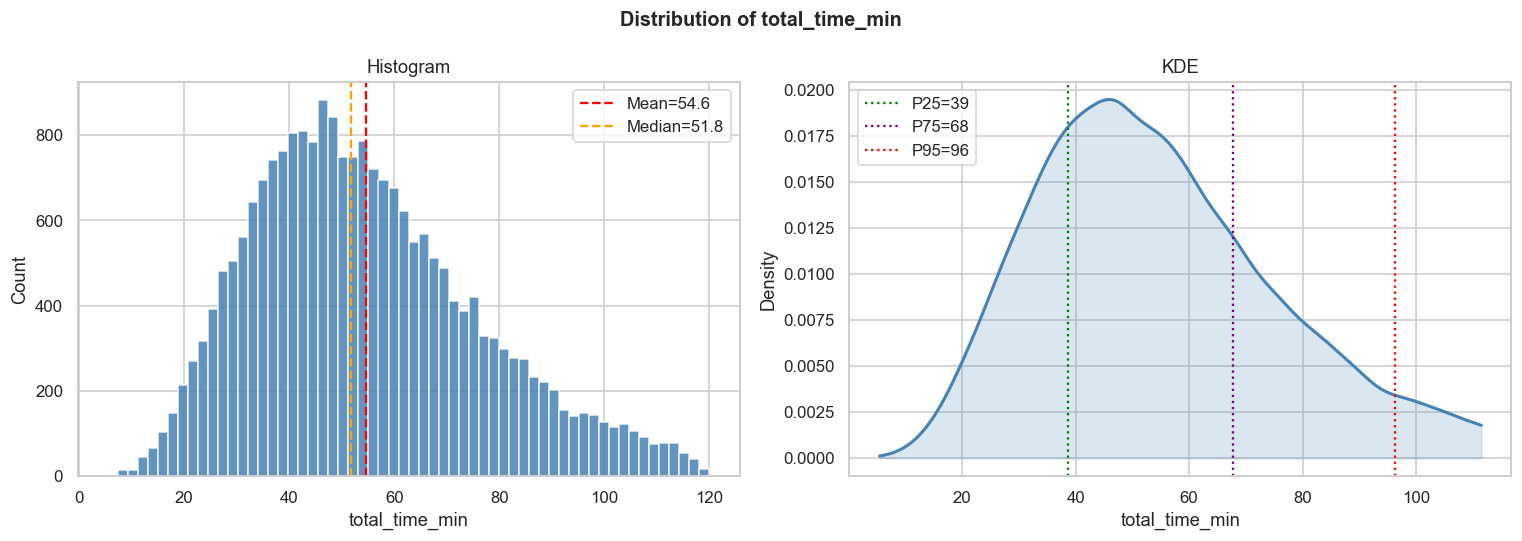

Figure saved


In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of total_time_min', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(df[TARGET], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df[TARGET].mean(),   color='red',    ls='--', lw=1.5, label=f'Mean={df[TARGET].mean():.1f}')
ax.axvline(df[TARGET].median(), color='orange', ls='--', lw=1.5, label=f'Median={df[TARGET].median():.1f}')
ax.set_xlabel('total_time_min'); ax.set_ylabel('Count')
ax.legend(); ax.set_title('Histogram')

from scipy.stats import gaussian_kde
ax2 = axes[1]
kde_x = np.linspace(df[TARGET].min(), df[TARGET].quantile(0.99), 300)
kde   = gaussian_kde(df[TARGET])
ax2.plot(kde_x, kde(kde_x), color='steelblue', lw=2)
ax2.fill_between(kde_x, kde(kde_x), alpha=0.2, color='steelblue')
for q, c, lab in [(0.25,'green','P25'), (0.75,'purple','P75'), (0.95,'red','P95')]:
    v = df[TARGET].quantile(q)
    ax2.axvline(v, color=c, ls=':', lw=1.5, label=f'{lab}={v:.0f}')
ax2.set_xlabel('total_time_min'); ax2.set_ylabel('Density')
ax2.legend(); ax2.set_title('KDE')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_01_totaltime_distribution.png', bbox_inches='tight')
plt.show()
print('Figure saved')

=== Average Time by Phase ===
                  Mean  Median    Std  Count  %Total
Wait Call         7.28    5.57   5.56  22085    13.3
Prepare Loading   7.18    4.92   6.67  22085    13.1
Loading          25.12   20.70  19.12  22085    46.0
Close Job        15.05   13.17   8.56  22085    27.6

  TOTAL (mean sum)      : 54.63 min


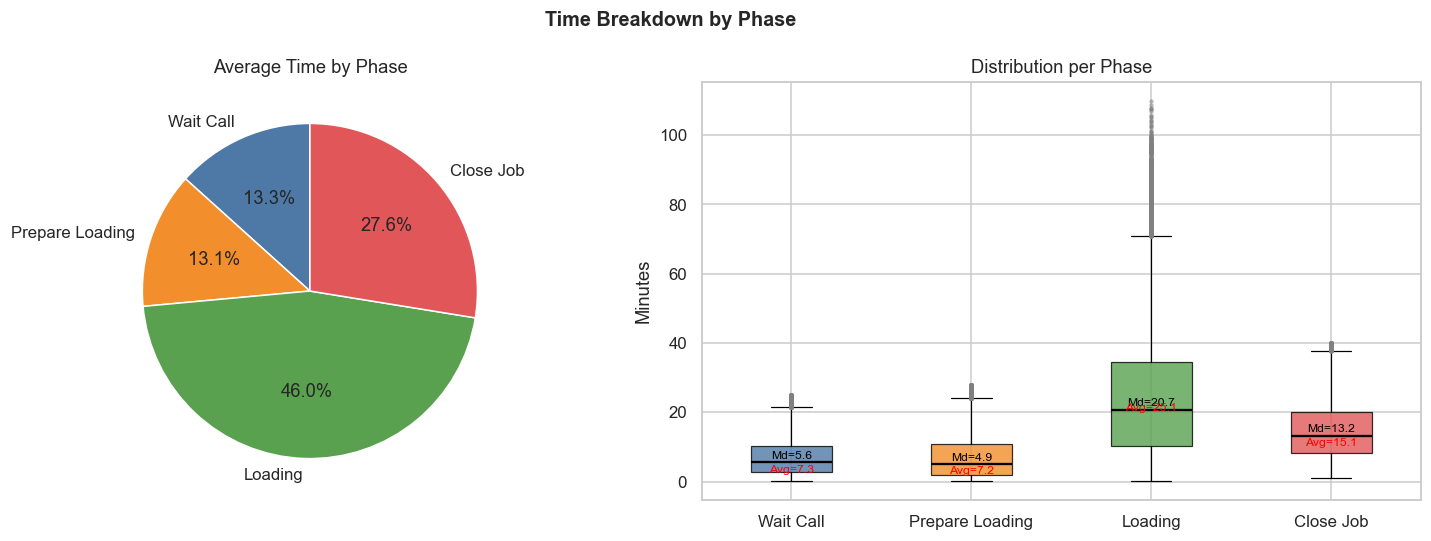

Figure saved


In [96]:
available    = [c for c in SUB_TIMES if c in df.columns]
phase_means  = df[available].mean()
phase_pct    = (phase_means / phase_means.sum() * 100).round(1)
COLORS       = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
LABELS       = ['Wait Call', 'Prepare Loading', 'Loading', 'Close Job']
labels_avail = LABELS[:len(available)]
color_avail  = COLORS[:len(available)]

# ── Phase Stats Table ──────────────────────────────────────────
phase_stats = df[available].agg(['mean', 'median', 'std', 'count']).T.round(2)
phase_stats.columns = ['Mean', 'Median', 'Std', 'Count']
phase_stats.index   = labels_avail
phase_stats['Count'] = phase_stats['Count'].astype(int)
phase_stats['%Total'] = phase_pct.values

print('=== Average Time by Phase ===')
print(phase_stats.to_string())
print(f'\n  {"TOTAL (mean sum)":22s}: {phase_means.sum():.2f} min')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Time Breakdown by Phase', fontsize=13, fontweight='bold')

axes[0].pie(phase_means.values, labels=labels_avail, autopct='%1.1f%%',
            colors=color_avail, startangle=90)
axes[0].set_title('Average Time by Phase')

groups = [df[c].dropna().values for c in available]
bp = axes[1].boxplot(
    groups, tick_labels=labels_avail, patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    boxprops=dict(linewidth=0.8),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    flierprops=dict(marker='.', markersize=4,
                    markerfacecolor='gray', markeredgecolor='gray', alpha=0.4),
)
for patch, c in zip(bp['boxes'], color_avail):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)

# annotate median & mean on boxplot
for i, (col, lbl) in enumerate(zip(available, labels_avail), start=1):
    med = df[col].median()
    avg = df[col].mean()
    axes[1].text(i, med + 0.5, f'Md={med:.1f}', ha='center', va='bottom', fontsize=8, color='black')
    axes[1].text(i, avg - 2.5, f'Avg={avg:.1f}', ha='center', va='top',    fontsize=8, color='red')

axes[1].set_title('Distribution per Phase'); axes[1].set_ylabel('Minutes')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_02_phase_breakdown.png', bbox_inches='tight')
plt.show()
print('Figure saved')


## 3. Segment Analysis

=== total_time_min by CarType ===
           Mean  Median    Std  Count
เทรเลอร์  69.03   68.36  22.15   7996
6 ล้อ     55.35   54.02  17.19    786
4 ล้อ     47.16   45.84  15.85  11822
10 ล้อ    36.08   34.15  14.78   1479


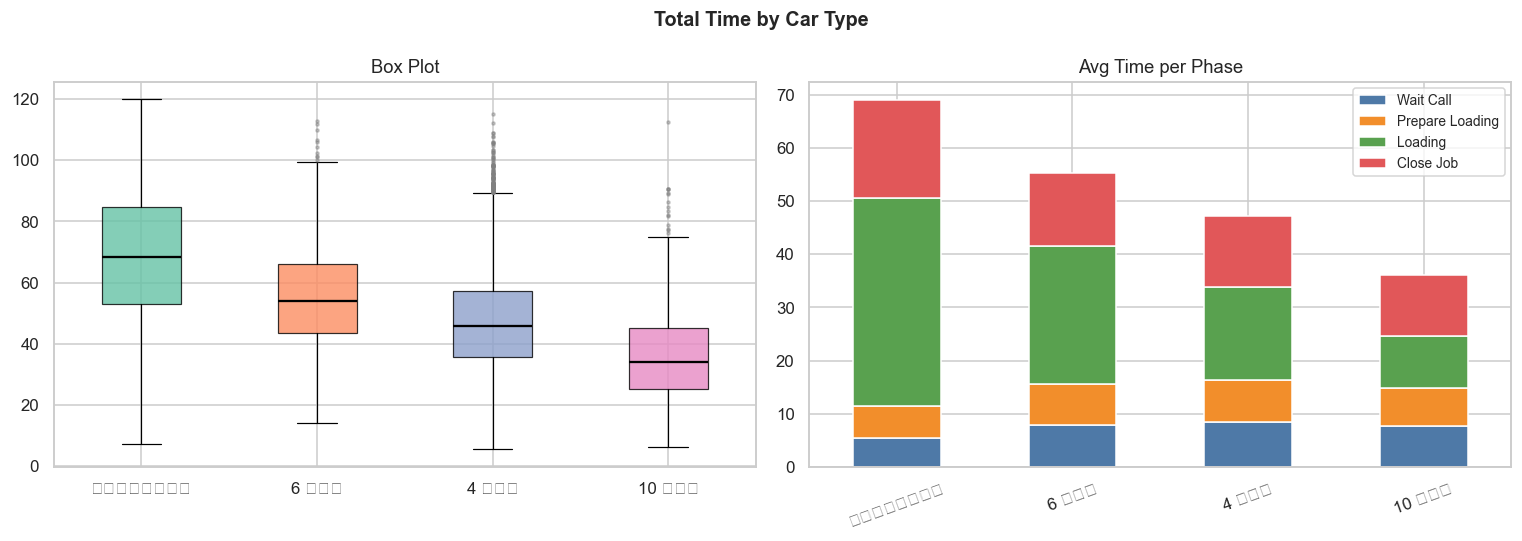

Figure saved


In [97]:
if 'CarType' in df.columns:
    dec_ct   = DECODE.get('CarType', {})
    ct_order = sorted(df['CarType'].dropna().unique().tolist())
    ct_label = [dec_ct.get(v, str(v)) for v in ct_order]

    ct_stats = (df.groupby('CarType')[TARGET]
                .agg(['mean','median','std','count']).loc[ct_order].round(2))
    ct_stats.index = ct_label
    ct_stats.columns = ['Mean','Median','Std','Count']
    ct_stats = ct_stats.sort_values('Mean', ascending=False)
    print('=== total_time_min by CarType ===')
    print(ct_stats.to_string())

    sorted_labels = ct_stats.index.tolist()
    sorted_codes  = [ct_order[ct_label.index(l)] for l in sorted_labels]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Total Time by Car Type', fontsize=13, fontweight='bold')

    grouped_boxplot(axes[0], df, 'CarType', TARGET,
                    order=sorted_codes, tick_labels=sorted_labels, palette='Set2')
    axes[0].set_title('Box Plot'); axes[0].set_xlabel('')

    if available:
        ct_phase = df.groupby('CarType')[available].mean().loc[sorted_codes]
        ct_phase.index = sorted_labels
        ct_phase.columns = labels_avail
        ct_phase.plot(kind='bar', stacked=True, ax=axes[1], color=color_avail)
        axes[1].set_title('Avg Time per Phase'); axes[1].set_xlabel('')
        axes[1].tick_params(axis='x', rotation=20)
        axes[1].legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    fig.savefig(FIGURE_DIR / 'eda_03_cartype.png', bbox_inches='tight')
    plt.show()
    print('Figure saved')

=== total_time_min by PickListType ===
           Mean  Median    Std  Count
SmartQ    48.91   46.88  18.40  12291
Walk-in   69.36   67.78  22.31    922
ล่วงหน้า  61.02   58.95  22.99   8872


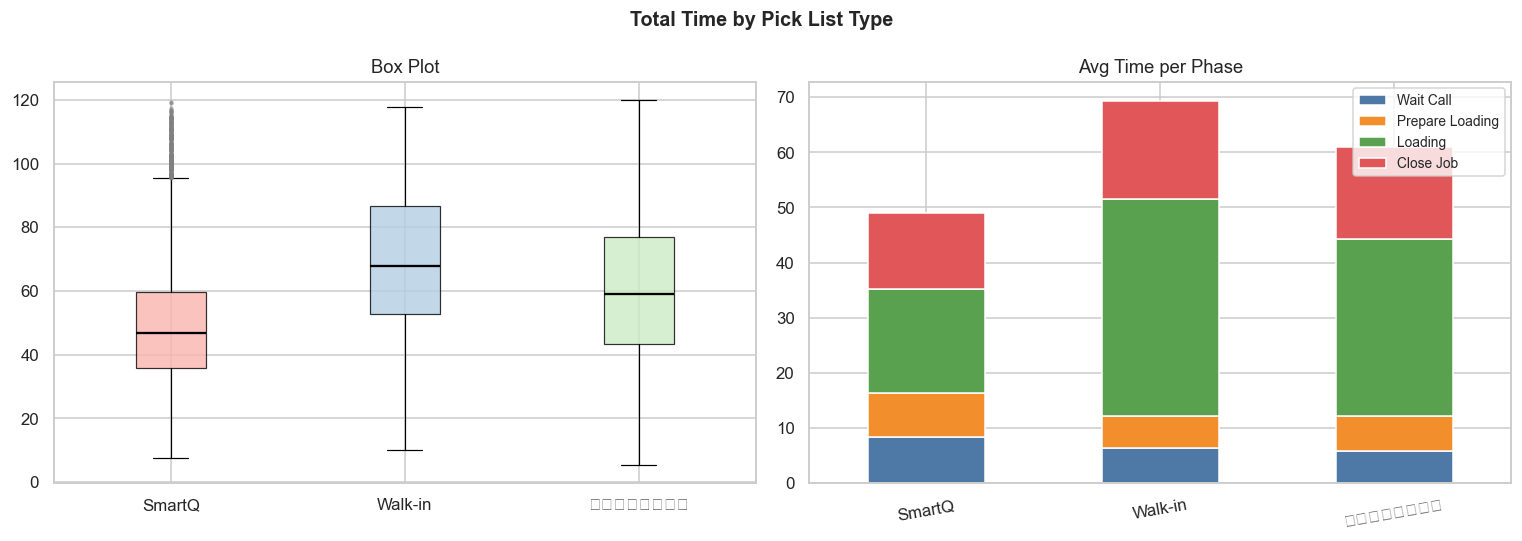

Figure saved


In [98]:
if 'PickListType' in df.columns:
    dec_pl   = DECODE.get('PickListType', {})
    pl_order = sorted(df['PickListType'].dropna().unique().tolist())
    pl_label = [dec_pl.get(v, str(v)) for v in pl_order]

    pl_stats = (df.groupby('PickListType')[TARGET]
                .agg(['mean','median','std','count']).loc[pl_order].round(2))
    pl_stats.index = pl_label
    pl_stats.columns = ['Mean','Median','Std','Count']
    print('=== total_time_min by PickListType ===')
    print(pl_stats.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Total Time by Pick List Type', fontsize=13, fontweight='bold')

    grouped_boxplot(axes[0], df, 'PickListType', TARGET,
                    order=pl_order, tick_labels=pl_label, palette='Pastel1')
    axes[0].set_title('Box Plot'); axes[0].set_xlabel('')

    if available:
        pl_phase = df.groupby('PickListType')[available].mean().loc[pl_order]
        pl_phase.index = pl_label
        pl_phase.columns = labels_avail
        pl_phase.plot(kind='bar', stacked=True, ax=axes[1], color=color_avail)
        axes[1].set_title('Avg Time per Phase'); axes[1].set_xlabel('')
        axes[1].tick_params(axis='x', rotation=10)
        axes[1].legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    fig.savefig(FIGURE_DIR / 'eda_04_picklist.png', bbox_inches='tight')
    plt.show()
    print('Figure saved')

## 6. Segment — PrepareForward

=== total_time_min by PrepareForward ===
    Mean  Median    Std  Count
N  49.02   46.93  18.48  12383
Y  61.78   59.77  23.05   9702

Diff (Y - N): +12.76 min


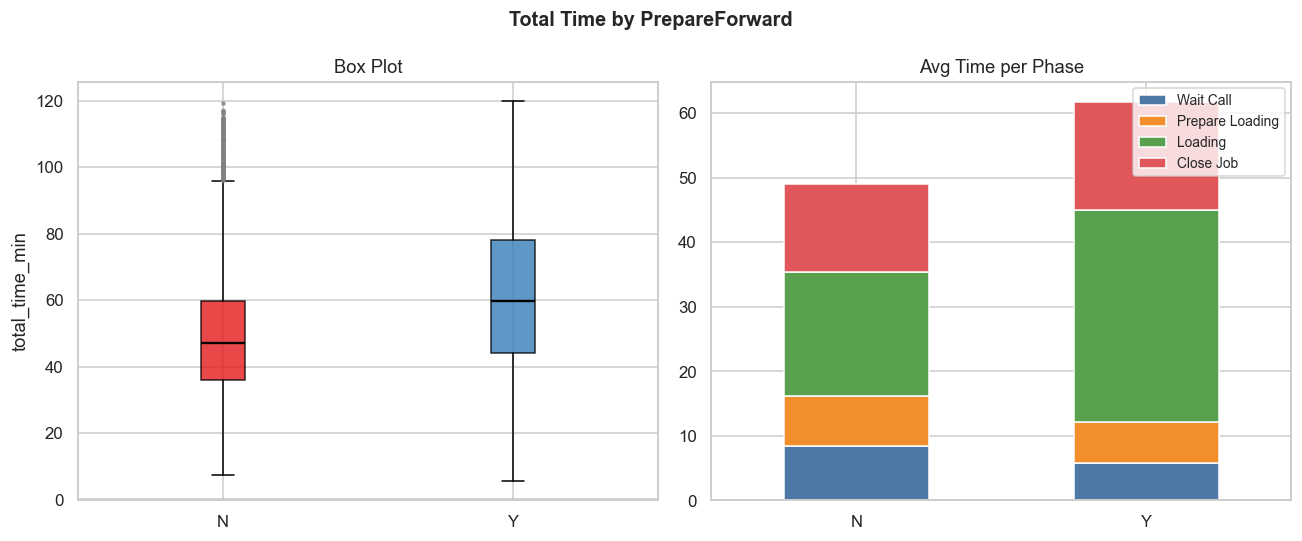

Figure saved


In [99]:
if 'PrepareForward' in df.columns:
    dec_pf   = DECODE['PrepareForward']
    pf_order = sorted(df['PrepareForward'].dropna().unique().tolist())
    pf_label = [dec_pf.get(v, str(v)) for v in pf_order]

    pf_stats = (df.groupby('PrepareForward')[TARGET + available if False else [TARGET] + available]
                .agg({TARGET: ['mean', 'median', 'std', 'count']})
                [TARGET].round(2))
    pf_stats.index = pf_label
    pf_stats.columns = ['Mean', 'Median', 'Std', 'Count']
    print('=== total_time_min by PrepareForward ===')
    print(pf_stats.to_string())

    diff = pf_stats.loc['Y', 'Mean'] - pf_stats.loc['N', 'Mean'] if 'Y' in pf_stats.index and 'N' in pf_stats.index else None
    if diff is not None:
        print(f'\nDiff (Y - N): {diff:+.2f} min')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Total Time by PrepareForward', fontsize=13, fontweight='bold')

    groups = [df[df['PrepareForward'] == g][TARGET].dropna().values for g in pf_order]
    colors = sns.color_palette('Set1', len(pf_order))
    bp = axes[0].boxplot(groups, tick_labels=pf_label, patch_artist=True,
                         medianprops=dict(color='black', linewidth=1.5),
                         flierprops=dict(marker='.', markersize=4, alpha=0.4, markerfacecolor='gray', markeredgecolor='gray'))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.8)
    axes[0].set_title('Box Plot'); axes[0].set_ylabel('total_time_min')

    if available:
        pf_phase = df.groupby('PrepareForward')[available].mean().loc[pf_order]
        pf_phase.index = pf_label
        pf_phase.columns = labels_avail
        pf_phase.plot(kind='bar', stacked=True, ax=axes[1], color=color_avail)
        axes[1].set_title('Avg Time per Phase')
        axes[1].tick_params(axis='x', rotation=0)
        axes[1].legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    fig.savefig(FIGURE_DIR / 'eda_06_prepareforward.png', bbox_inches='tight')
    plt.show()
    print('Figure saved')

=== total_time_min by PostLocationName ===
                     Mean  Median    Std  Count
อุปกรณ์             60.30   57.12  23.59   3000
ลาน2-ช1 (Prestige)  58.88   56.08  21.22   1614
Zone 10.0           55.37   52.25  20.87   5228
ลาน3-ช2 (ครอบ)      55.03   53.45  21.67   2891
ลาน1-ช1 (CPAC)      54.42   49.96  22.88     62
ลาน1-ช3 (CPAC)      54.04   51.68  20.02   3818
ลาน3-ช1 (ครอบ)      51.32   47.95  21.06   2886
ลาน2-ช3 (Prestige)  49.22   46.15  20.53   2039
ลาน2-ช2 (Prestige)  45.87   41.26  20.95    438
Zone 11.0           33.48   28.02  20.56    109


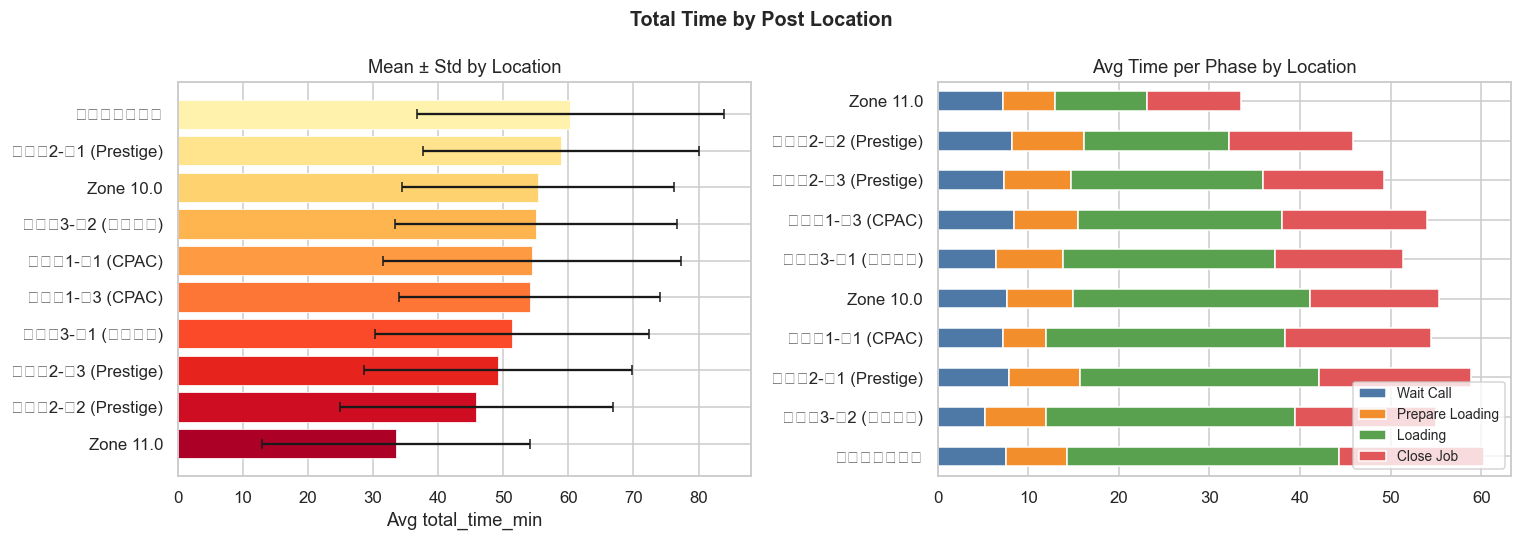

Figure saved


In [100]:
## 7. Segment — PostLocationName
if 'PostLocationName' in df.columns:
    LOC_DECODE = {
        0: 'SB1-ลานโอน',
        1: 'ลาน1-ช1 (CPAC)',
        2: 'ลาน1-ช2 (CPAC)',
        3: 'ลาน1-ช3 (CPAC)',
        4: 'ลาน2-ช1 (Prestige)',
        5: 'ลาน2-ช2 (Prestige)',
        6: 'ลาน2-ช3 (Prestige)',
        7: 'ลาน3-ช1 (ครอบ)',
        8: 'ลาน3-ช2 (ครอบ)',
        9: 'อุปกรณ์',
    }

    loc_stats = (df.groupby('PostLocationName')[TARGET]
                 .agg(['mean', 'median', 'std', 'count'])
                 .sort_values('mean', ascending=False).round(2))
    loc_stats.index = [LOC_DECODE.get(i, f'Zone {i}') for i in loc_stats.index]
    loc_stats.columns = ['Mean', 'Median', 'Std', 'Count']
    print('=== total_time_min by PostLocationName ===')
    print(loc_stats.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Total Time by Post Location', fontsize=13, fontweight='bold')

    colors_loc = sns.color_palette('YlOrRd', len(loc_stats))
    axes[0].barh(loc_stats.index[::-1], loc_stats['Mean'][::-1],
                 xerr=loc_stats['Std'][::-1], color=colors_loc[::-1],
                 capsize=3, edgecolor='white', linewidth=0.5)
    axes[0].set_xlabel('Avg total_time_min')
    axes[0].set_title('Mean ± Std by Location')

    if available:
        loc_codes = (df.groupby('PostLocationName')[available].mean()
                     .sort_values(available[2] if len(available) > 2 else available[0],
                                  ascending=False))
        loc_codes.index = [LOC_DECODE.get(i, f'Zone {i}') for i in loc_codes.index]
        loc_codes.columns = labels_avail
        loc_codes.plot(kind='barh', stacked=True, ax=axes[1], color=color_avail)
        axes[1].set_title('Avg Time per Phase by Location')
        axes[1].legend(loc='lower right', fontsize=9)

    plt.tight_layout()
    fig.savefig(FIGURE_DIR / 'eda_07_location.png', bbox_inches='tight')
    plt.show()
    print('Figure saved')

=== Avg total_time_min by Hour ===
       mean  median  count
hour                      
6     53.60   47.56     30
7     55.51   52.97   2730
8     53.32   48.95   1729
9     54.56   52.33   1757
10    52.38   48.61   1912
11    54.18   50.52   1881
12    55.40   52.42   1888
13    54.36   51.16   2164
14    54.60   51.98   2488
15    54.54   51.55   2321
16    55.63   53.82   2030
17    57.01   54.52    833
18    56.68   55.87    257
19    55.28   55.05     57
20    52.42   57.13      7
21    25.25   25.25      1


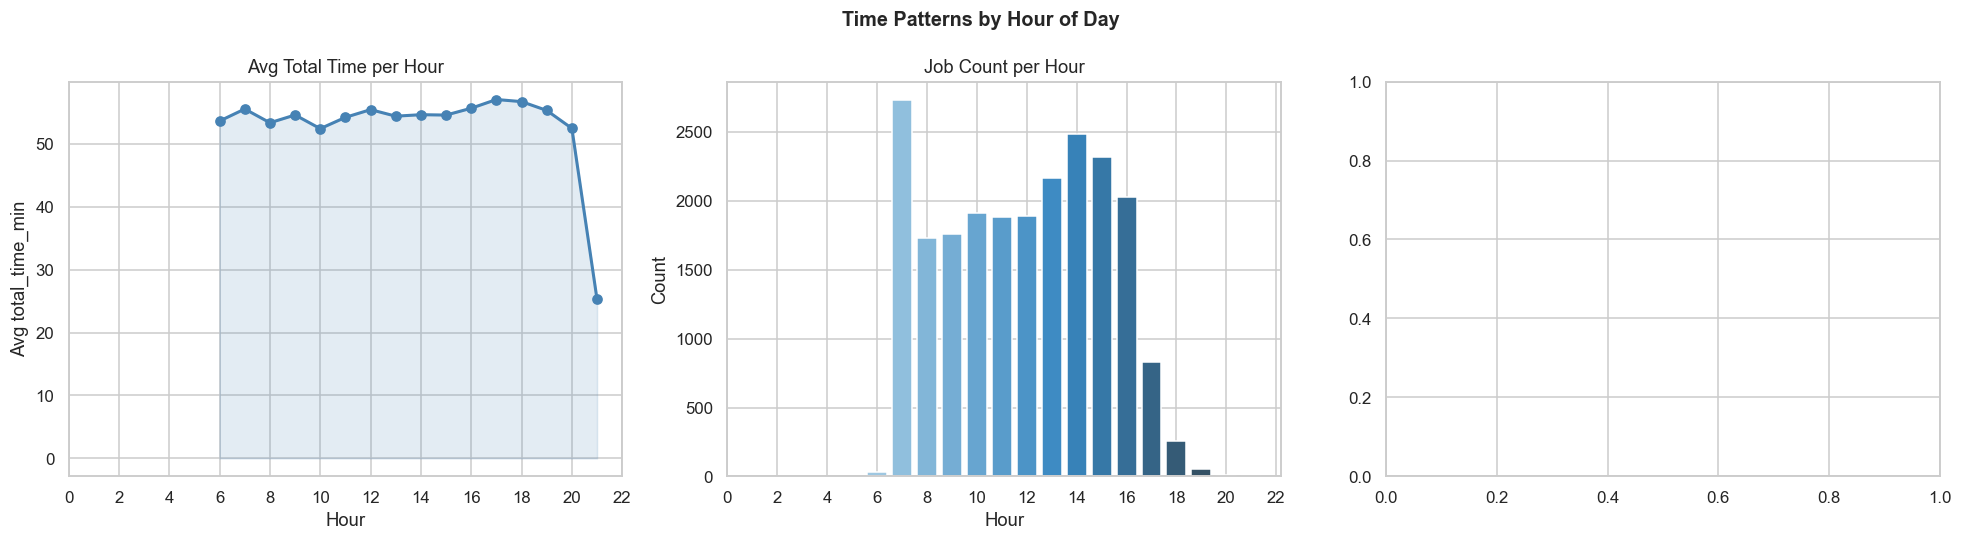

Figure saved


In [101]:
## 8. Time Patterns — Hour
if 'hour' in df.columns:
    hour_stats = df.groupby('hour')[TARGET].agg(['mean', 'median', 'count'])
    print('=== Avg total_time_min by Hour ===')
    print(hour_stats.round(2).to_string())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Time Patterns by Hour of Day', fontsize=13, fontweight='bold')

    # Mean per hour line chart
    ax = axes[0]
    ax.plot(hour_stats.index, hour_stats['mean'], 'o-', color='steelblue', ms=6, lw=2)
    ax.fill_between(hour_stats.index, hour_stats['mean'], alpha=0.15, color='steelblue')
    ax.set_xlabel('Hour'); ax.set_ylabel('Avg total_time_min')
    ax.set_title('Avg Total Time per Hour')
    ax.set_xticks(range(0, 24, 2))

    # Transaction count per hour
    ax = axes[1]
    ax.bar(hour_stats.index, hour_stats['count'],
           color=sns.color_palette('Blues_d', len(hour_stats)), edgecolor='white')
    ax.set_xlabel('Hour'); ax.set_ylabel('Count')
    ax.set_title('Job Count per Hour')
    ax.set_xticks(range(0, 24, 2))

    # hour_sin vs hour_cos scatter colored by total_time
    ax = axes[2]
    if 'hour_sin' in df.columns and 'hour_cos' in df.columns:
        sc = ax.scatter(df['hour_cos'], df['hour_sin'],
                        c=df[TARGET], cmap='YlOrRd', s=8, alpha=0.4)
        plt.colorbar(sc, ax=ax, label='total_time_min')
        ax.set_xlabel('hour_cos'); ax.set_ylabel('hour_sin')
        ax.set_title('Cyclical Hour Encoding\n(colored by total_time_min)')
        for h in [0, 6, 12, 18]:
            rad = 2 * np.pi * h / 24
            ax.annotate(f'{h}:00',
                        xy=(np.cos(rad), np.sin(rad)),
                        xytext=(np.cos(rad) * 1.15, np.sin(rad) * 1.15),
                        fontsize=8, ha='center',
                        arrowprops=dict(arrowstyle='->', lw=0.8))

    plt.tight_layout()
    fig.savefig(FIGURE_DIR / 'eda_08_hour_patterns.png', bbox_inches='tight')
    plt.show()
    print('Figure saved')

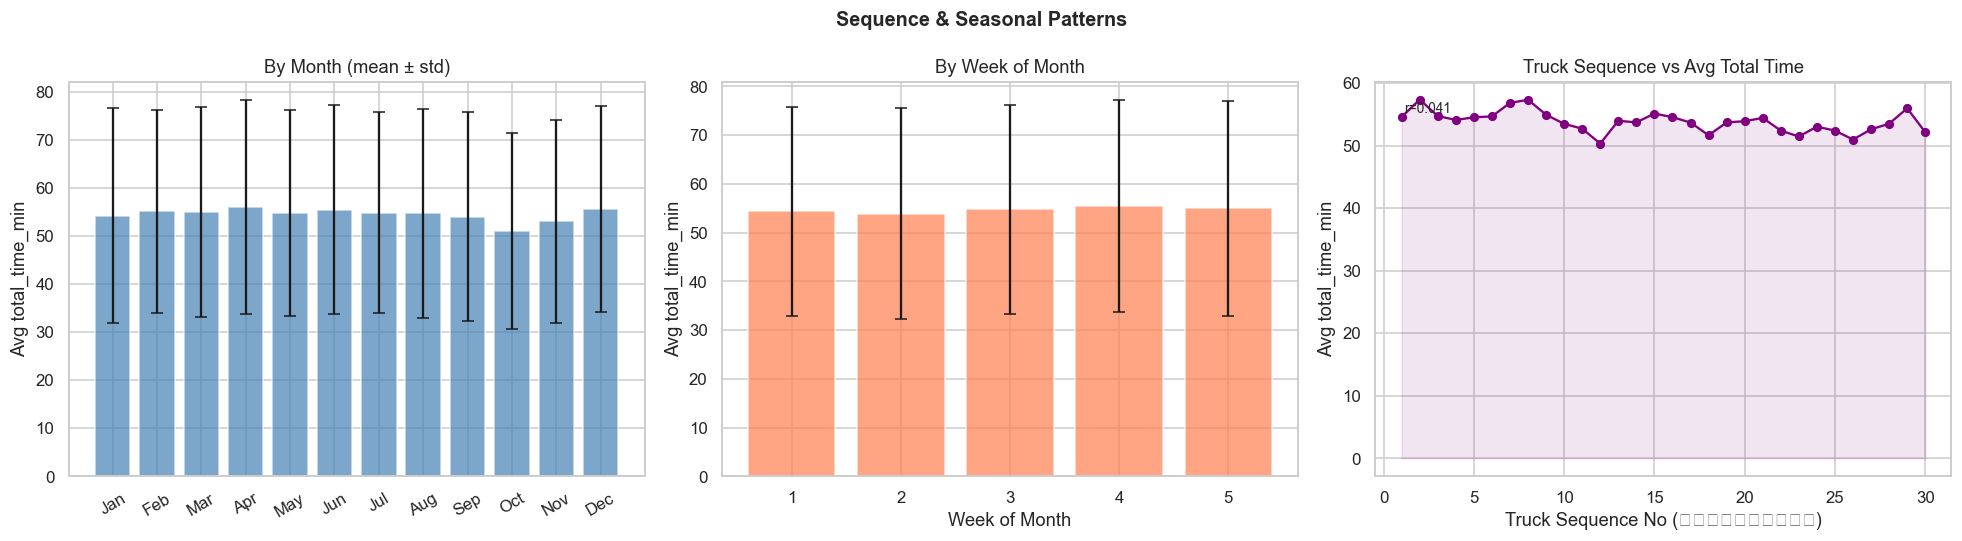

Figure saved


In [102]:
## 9. Truck Sequence & Month / WeekOfMonth Patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sequence & Seasonal Patterns', fontsize=13, fontweight='bold')

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

if 'month' in df.columns:
    month_stats = df.groupby('month')[TARGET].agg(['mean', 'std'])
    x = month_stats.index
    axes[0].bar(x, month_stats['mean'], yerr=month_stats['std'],
                color='steelblue', alpha=0.7, capsize=4, error_kw={'lw': 1.5})
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([month_names[m - 1] for m in x], rotation=30)
    axes[0].set_title('By Month (mean ± std)')
    axes[0].set_ylabel('Avg total_time_min')

if 'week_of_month' in df.columns:
    wom = df.groupby('week_of_month')[TARGET].agg(['mean', 'std'])
    axes[1].bar(wom.index, wom['mean'], yerr=wom['std'],
                color='coral', alpha=0.7, capsize=4, error_kw={'lw': 1.5})
    axes[1].set_title('By Week of Month')
    axes[1].set_xlabel('Week of Month')
    axes[1].set_ylabel('Avg total_time_min')

if 'TruckSeqNo' in df.columns:
    seq = df[df['TruckSeqNo'] <= 30].groupby('TruckSeqNo')[TARGET].agg(['mean', 'count'])
    seq = seq[seq['count'] >= 10]
    axes[2].plot(seq.index, seq['mean'], 'o-', color='purple', ms=5, lw=1.5)
    axes[2].fill_between(seq.index, seq['mean'], alpha=0.1, color='purple')
    axes[2].set_xlabel('Truck Sequence No (ลำดับในวัน)')
    axes[2].set_ylabel('Avg total_time_min')
    axes[2].set_title('Truck Sequence vs Avg Total Time')
    r_seq = df['TruckSeqNo'].corr(df[TARGET])
    axes[2].text(0.05, 0.92, f'r={r_seq:.3f}', transform=axes[2].transAxes, fontsize=9)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_09_sequence_seasonal.png', bbox_inches='tight')
plt.show()
print('Figure saved')

## 10. Product & SAP Analysis

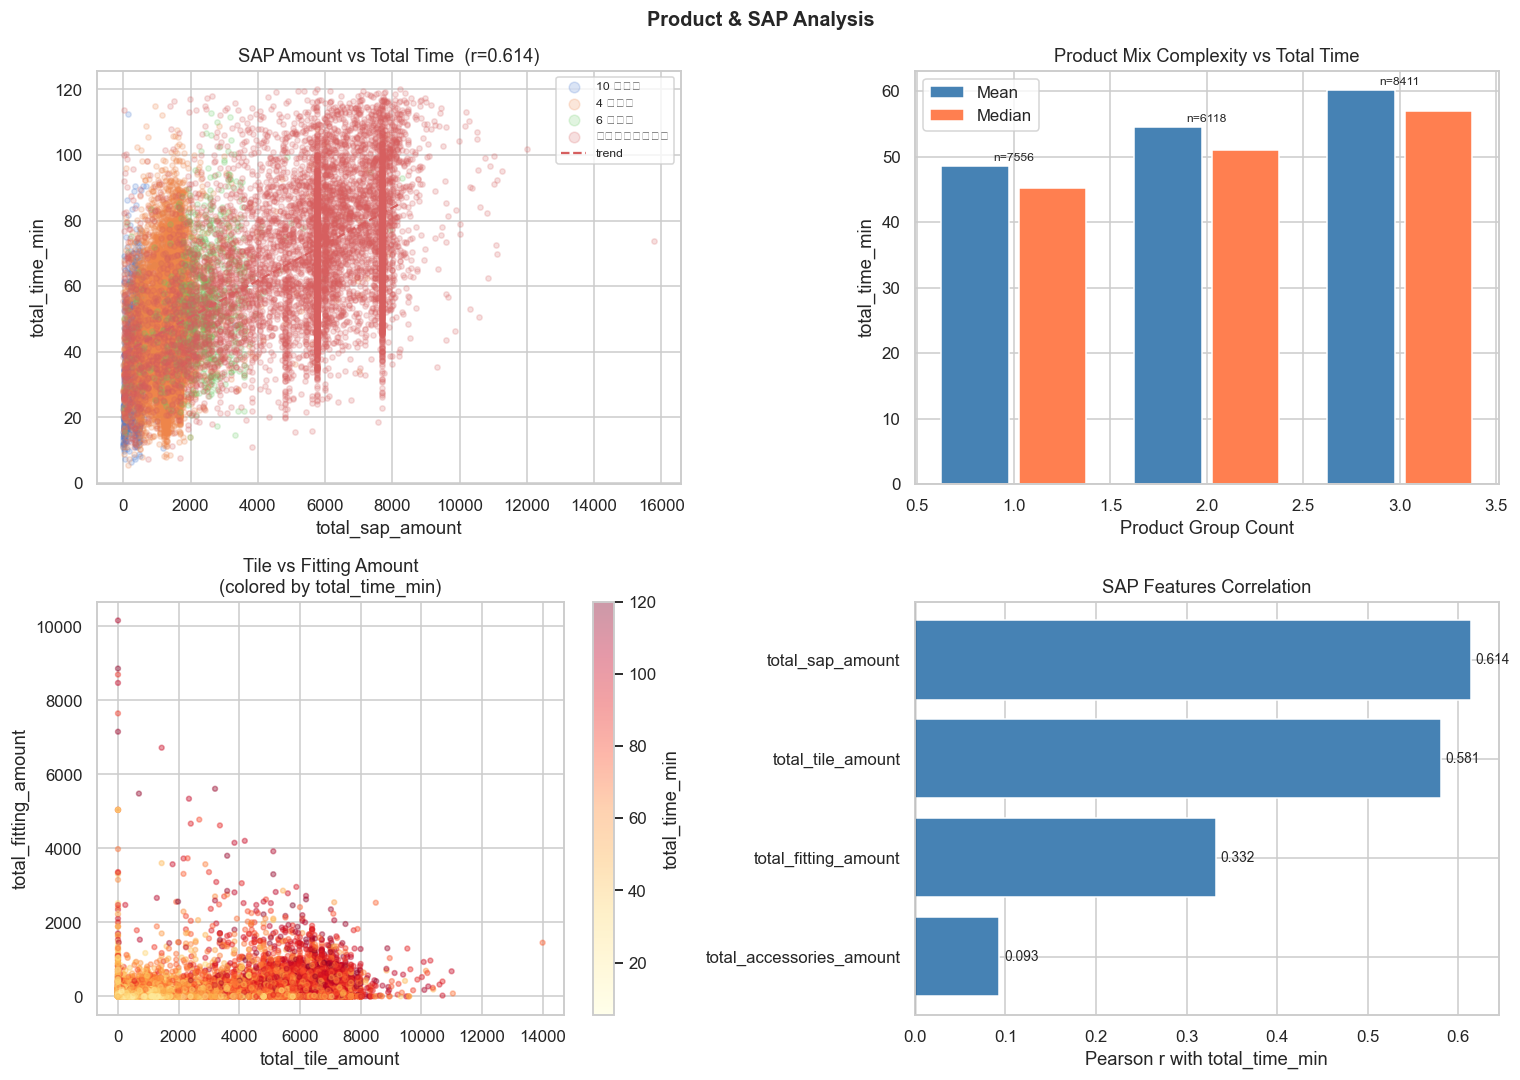

Figure saved


In [103]:
sap_cols = ['total_tile_amount', 'total_fitting_amount', 'total_accessories_amount', 'total_sap_amount']
sap_present = [c for c in sap_cols if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Product & SAP Analysis', fontsize=13, fontweight='bold')

# total_sap_amount scatter by CarType
ax = axes[0, 0]
if 'total_sap_amount' in df.columns and 'CarType' in df.columns:
    dec_ct = DECODE['CarType']
    for v in sorted(df['CarType'].dropna().unique()):
        sub = df[df['CarType'] == v]
        ax.scatter(sub['total_sap_amount'], sub[TARGET],
                   alpha=0.2, s=12, label=dec_ct.get(v, str(v)))
    r_sap = df['total_sap_amount'].corr(df[TARGET])
    z = np.polyfit(df['total_sap_amount'].fillna(0), df[TARGET], 1)
    xr = np.linspace(0, df['total_sap_amount'].quantile(0.99), 100)
    ax.plot(xr, np.poly1d(z)(xr), 'r--', lw=1.5, label=f'trend')
    ax.set_xlabel('total_sap_amount'); ax.set_ylabel('total_time_min')
    ax.set_title(f'SAP Amount vs Total Time  (r={r_sap:.3f})')
    ax.legend(fontsize=8, markerscale=2)

# product_group_count bar
ax = axes[0, 1]
if 'product_group_count' in df.columns:
    pgc = df.groupby('product_group_count')[TARGET].agg(['mean', 'median', 'count'])
    x = pgc.index.to_numpy()
    ax.bar(x - 0.2, pgc['mean'],   width=0.35, label='Mean',   color='steelblue')
    ax.bar(x + 0.2, pgc['median'], width=0.35, label='Median', color='coral')
    for xi, row in pgc.iterrows():
        ax.text(xi, row['mean'] + 0.8, f'n={int(row["count"])}', ha='center', fontsize=8)
    ax.set_xlabel('Product Group Count'); ax.set_ylabel('total_time_min')
    ax.set_title('Product Mix Complexity vs Total Time')
    ax.legend()

# tile vs fitting scatter
ax = axes[1, 0]
if 'total_tile_amount' in df.columns and 'total_fitting_amount' in df.columns:
    sc = ax.scatter(df['total_tile_amount'], df['total_fitting_amount'],
                    c=df[TARGET], cmap='YlOrRd', s=10, alpha=0.4)
    plt.colorbar(sc, ax=ax, label='total_time_min')
    ax.set_xlabel('total_tile_amount'); ax.set_ylabel('total_fitting_amount')
    ax.set_title('Tile vs Fitting Amount\n(colored by total_time_min)')

# correlation of each SAP col with target
ax = axes[1, 1]
if sap_present:
    r_vals = pd.Series({c: df[c].corr(df[TARGET]) for c in sap_present}).sort_values()
    colors_bar = ['coral' if v < 0 else 'steelblue' for v in r_vals.values]
    ax.barh(r_vals.index, r_vals.values, color=colors_bar)
    ax.axvline(0, color='black', lw=0.8)
    for i, (idx, val) in enumerate(r_vals.items()):
        ax.text(val + (0.005 if val >= 0 else -0.005), i,
                f'{val:.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=9)
    ax.set_xlabel('Pearson r with total_time_min')
    ax.set_title('SAP Features Correlation')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_10_product_sap.png', bbox_inches='tight')
plt.show()
print('Figure saved')

## 11. Average Time by CarType Features

In [104]:
avg_cartype_cols = [
    'avg_wait_call_by_cartype',
    'avg_prepare_loading_by_cartype',
    'avg_loading_time_by_cartype',
    'avg_close_job_by_cartype',
    'avg_total_time_by_cartype',
]
avg_present = [c for c in avg_cartype_cols if c in df.columns]

if avg_present:
    dec_ct = DECODE['CarType']

    # Summary table
    summary = (df.groupby('CarType')[avg_present].first()
               .rename(index=dec_ct))
    summary.index.name = 'CarType'
    print('=== Average Time Features by CarType ===')
    print(summary.round(2).to_string())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Average Time by CarType Features', fontsize=13, fontweight='bold')

    # Bar chart: avg time per phase per cartype
    ax = axes[0]
    phase_avg_cols = [c for c in avg_present if 'total' not in c]
    if phase_avg_cols:
        bar_data = df.groupby('CarType')[phase_avg_cols].first().rename(index=dec_ct)
        bar_data.columns = [c.replace('avg_', '').replace('_by_cartype', '').replace('_', ' ') for c in phase_avg_cols]
        bar_data.plot(kind='bar', ax=ax, color=color_avail[:len(phase_avg_cols)])
        ax.set_title('Avg Phase Time by CarType')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=20)
        ax.legend(fontsize=8)
        ax.set_ylabel('Minutes')

    # Scatter: avg_total_time_by_cartype vs actual total_time_min
    ax = axes[1]
    if 'avg_total_time_by_cartype' in df.columns:
        for v in sorted(df['CarType'].dropna().unique()):
            sub = df[df['CarType'] == v]
            ax.scatter(sub['avg_total_time_by_cartype'], sub[TARGET],
                       alpha=0.25, s=12, label=dec_ct.get(v, str(v)))
        r_avg = df['avg_total_time_by_cartype'].corr(df[TARGET])
        ax.set_xlabel('avg_total_time_by_cartype')
        ax.set_ylabel('actual total_time_min')
        ax.set_title(f'Avg vs Actual Total Time\n(r={r_avg:.3f})')
        ax.legend(fontsize=8, markerscale=2)

    # Correlation bar
    ax = axes[2]
    r_avgs = pd.Series({c: df[c].corr(df[TARGET]) for c in avg_present}).sort_values()
    short_names = [c.replace('avg_', '').replace('_by_cartype', '').replace('_', '\n') for c in r_avgs.index]
    colors_bar = ['coral' if v < 0 else 'steelblue' for v in r_avgs.values]
    ax.barh(short_names, r_avgs.values, color=colors_bar)
    ax.axvline(0, color='black', lw=0.8)
    for i, val in enumerate(r_avgs.values):
        ax.text(val + (0.005 if val >= 0 else -0.005), i,
                f'{val:.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=9)
    ax.set_xlabel('Pearson r with total_time_min')
    ax.set_title('avg_xxx_by_cartype Correlation')

    plt.tight_layout()
    fig.savefig(FIGURE_DIR / 'eda_11_avg_cartype.png', bbox_inches='tight')
    plt.show()
    print('Figure saved')

## 12. Correlation Analysis — ครบทุก Feature

=== Correlation กับ total_time_min (ครบทุก feature = 39 ตัว) ===
Feature                                          r
----------------------------------------------------
total_sap_amount                          +0.6140  +████████████
car_type_x_sap                            +0.6030  +████████████
total_tile_amount                         +0.5806  +███████████
CarType                                   +0.5241  +██████████
avg_time_by_cartype                       +0.5241  +██████████
rolling_avg_cartype_last10                +0.4737  +█████████
CPACTileSapAmount                         +0.3992  +███████
sap_per_group                             +0.3850  +███████
total_fitting_amount                      +0.3325  +██████
queue_x_sap                               +0.3013  +██████
PrepareForward                            +0.2937  +█████
CPACFittingSapAmount                      +0.2928  +█████
PickListType                              +0.2759  +█████
PRESTIGETileSapAmount                

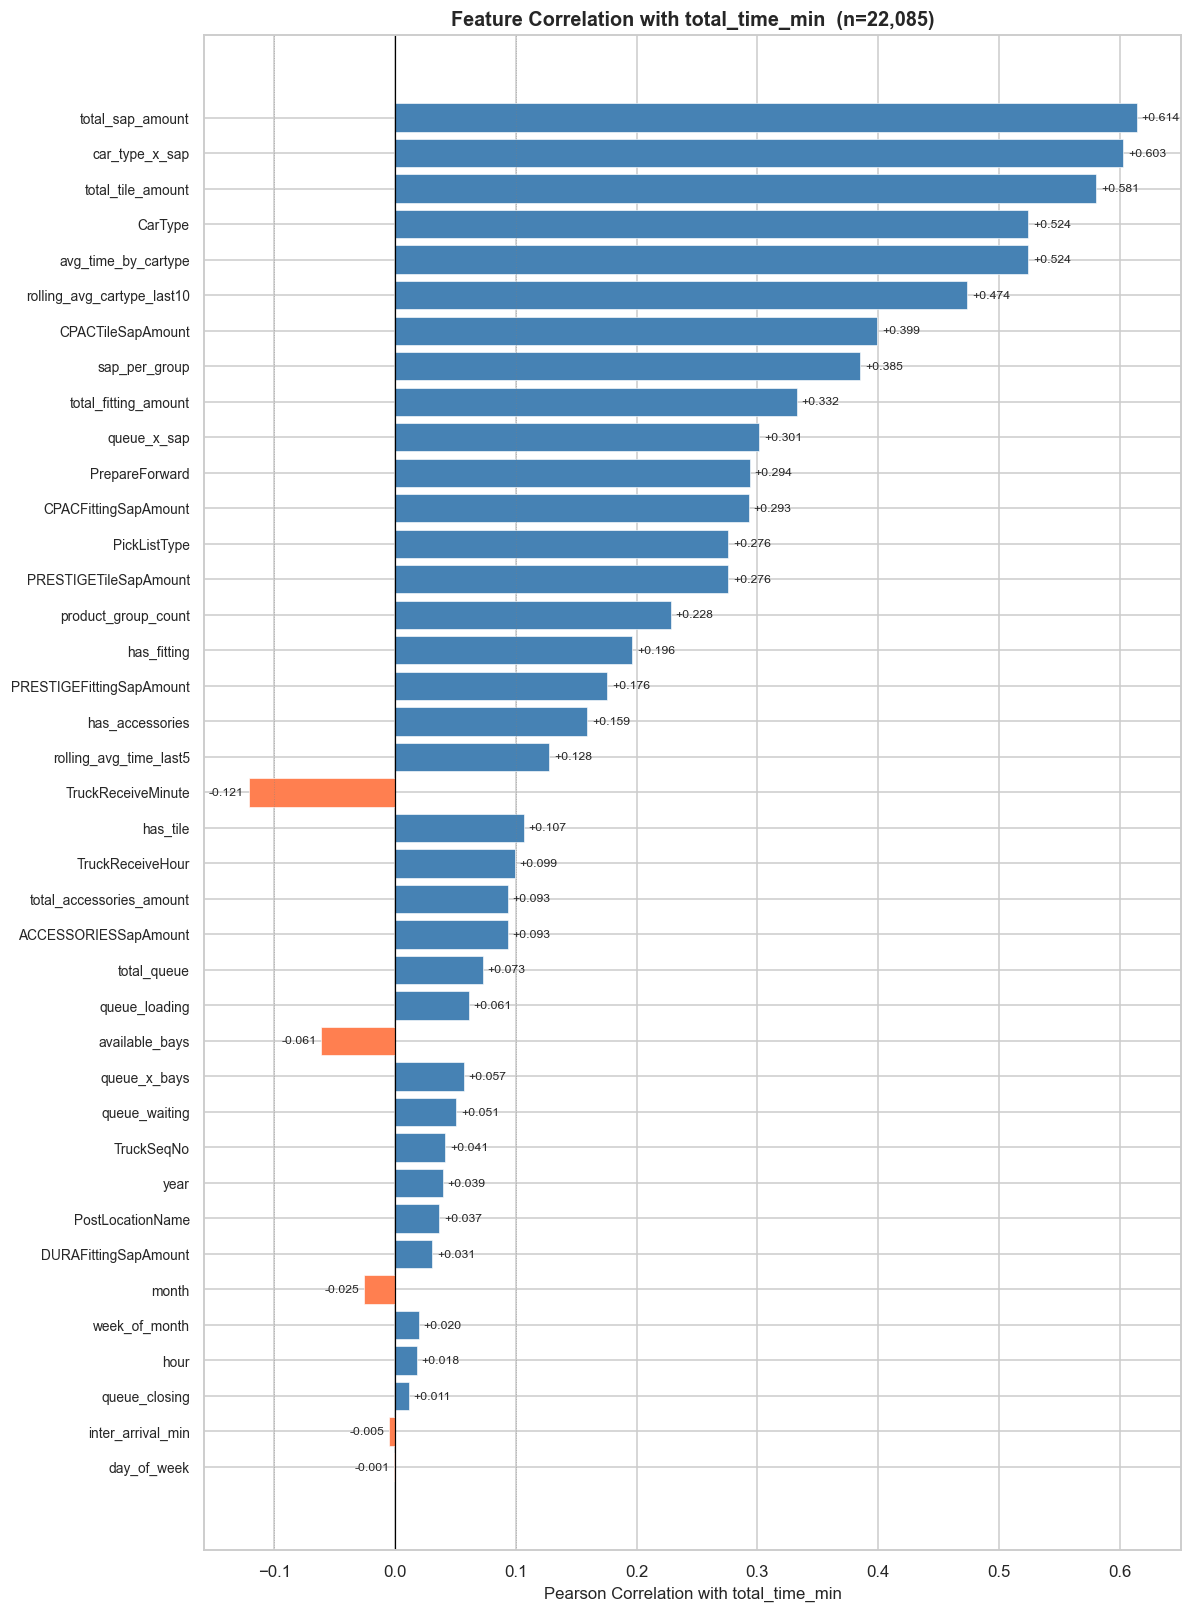

Figure saved


In [105]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
leaky        = set(SUB_TIMES)
feat_cols    = [c for c in numeric_cols if c not in leaky and c != TARGET]

corr_target = (df[feat_cols + [TARGET]].corr()[TARGET]
               .drop(TARGET)
               .dropna()
               .sort_values(key=abs, ascending=False))

print(f'=== Correlation กับ {TARGET} (ครบทุก feature = {len(corr_target)} ตัว) ===')
print(f'{"Feature":<40}  {"r":>8}')
print('-' * 52)
for feat, val in corr_target.items():
    bar = '█' * int(abs(val) * 20)
    direction = '+' if val >= 0 else '-'
    print(f'{feat:<40}  {val:+.4f}  {direction}{bar}')

# ---- Bar chart ครบทุก feature ----
n_feats = len(corr_target)
fig_h   = max(8, n_feats * 0.38)

fig, ax = plt.subplots(figsize=(11, fig_h))
bar_colors = ['steelblue' if v > 0 else 'coral' for v in corr_target.values]
bars = ax.barh(corr_target.index[::-1], corr_target.values[::-1],
               color=bar_colors[::-1], edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', lw=0.8)
ax.axvline( 0.1, color='gray', lw=0.6, ls=':', alpha=0.5)
ax.axvline(-0.1, color='gray', lw=0.6, ls=':', alpha=0.5)
ax.set_xlabel('Pearson Correlation with total_time_min', fontsize=11)
ax.set_title(f'Feature Correlation with total_time_min  (n={len(df):,})',
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, corr_target.values[::-1]):
    offset = 0.004 if val >= 0 else -0.004
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=8)

ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_12_all_features_correlation.png', bbox_inches='tight')
plt.show()
print('Figure saved')

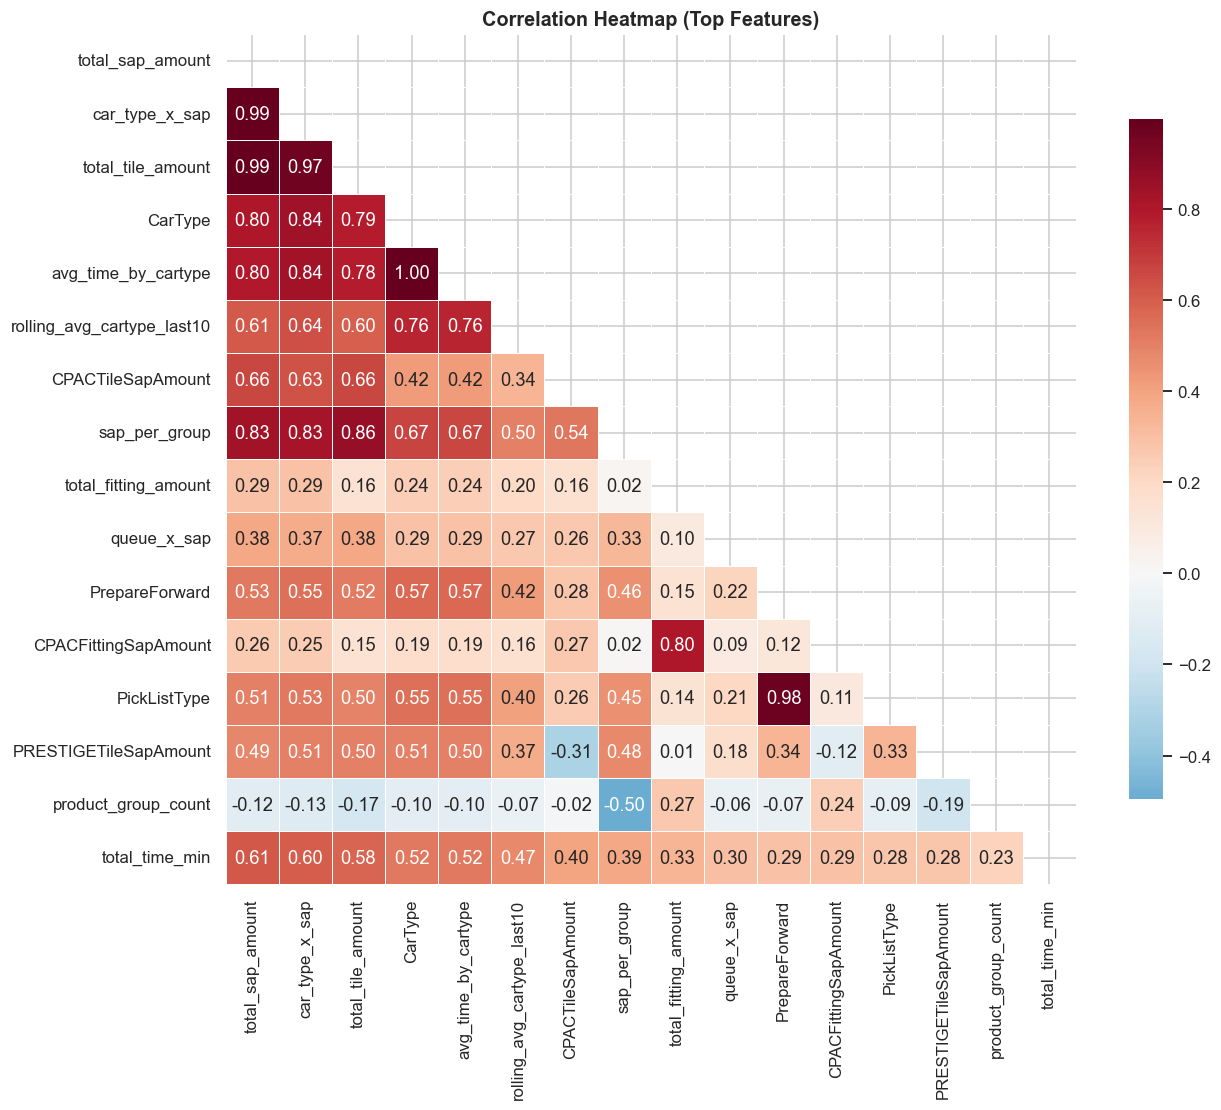

Figure saved


In [106]:
top_features = corr_target.head(15).index.tolist() + [TARGET]
corr_matrix  = df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Top Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_11_corr_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure saved')

## 13. Business Insights Summary

In [107]:
p95 = df[TARGET].quantile(0.95)
p05 = df[TARGET].quantile(0.05)
slow_trucks = df[df[TARGET] >= p95]
fast_trucks = df[df[TARGET] <= p05]

print(f'Slow (>= P95 = {p95:.1f} min): {len(slow_trucks):,} rows ({len(slow_trucks)/len(df)*100:.1f}%)')
print(f'Fast (<= P05 = {p05:.1f} min): {len(fast_trucks):,} rows ({len(fast_trucks)/len(df)*100:.1f}%)')

if 'CarType' in df.columns:
    dec_ct = DECODE['CarType']
    slow_ct = slow_trucks['CarType'].map(dec_ct).value_counts(normalize=True).mul(100).round(1)
    all_ct  = df['CarType'].map(dec_ct).value_counts(normalize=True).mul(100).round(1)
    print('\nCarType Distribution — Slow% vs All%:')
    print(pd.DataFrame({'Slow%': slow_ct, 'All%': all_ct}).fillna(0).sort_values('Slow%', ascending=False).to_string())

    fast_ct = fast_trucks['CarType'].map(dec_ct).value_counts(normalize=True).mul(100).round(1)
    print('\nCarType Distribution — Fast% vs All%:')
    print(pd.DataFrame({'Fast%': fast_ct, 'All%': all_ct}).fillna(0).sort_values('Fast%', ascending=False).to_string())

if 'PickListType' in df.columns:
    dec_pl = DECODE['PickListType']
    slow_pl = slow_trucks['PickListType'].map(dec_pl).value_counts(normalize=True).mul(100).round(1)
    all_pl  = df['PickListType'].map(dec_pl).value_counts(normalize=True).mul(100).round(1)
    print('\nPickListType Distribution — Slow% vs All%:')
    print(pd.DataFrame({'Slow%': slow_pl, 'All%': all_pl}).fillna(0).sort_values('Slow%', ascending=False).to_string())

Slow (>= P95 = 96.3 min): 1,106 rows (5.0%)
Fast (<= P05 = 24.0 min): 1,109 rows (5.0%)

CarType Distribution — Slow% vs All%:
          Slow%  All%
CarType              
เทรเลอร์   95.1  36.2
4 ล้อ       3.6  53.5
6 ล้อ       1.2   3.6
10 ล้อ      0.1   6.7

CarType Distribution — Fast% vs All%:
          Fast%  All%
CarType              
4 ล้อ      59.9  53.5
10 ล้อ     29.5   6.7
เทรเลอร์    9.5  36.2
6 ล้อ       1.2   3.6

PickListType Distribution — Slow% vs All%:
              Slow%  All%
PickListType             
ล่วงหน้า       68.6  40.2
SmartQ         19.1  55.7
Walk-in        12.3   4.2


In [108]:
print('=' * 65)
print('BUSINESS INSIGHTS — Total Time Prediction')
print('=' * 65)

print(f'\n[Overview]')
print(f'  Records   : {len(df):,}')
print(f'  Avg total : {df[TARGET].mean():.1f} min')
print(f'  Median    : {df[TARGET].median():.1f} min')
print(f'  P95       : {df[TARGET].quantile(0.95):.1f} min')
print(f'  Skewness  : {scipy_stats.skew(df[TARGET]):.3f}')

if available:
    phase_pcts = (df[available].mean() / df[available].mean().sum() * 100).round(1)
    print('\n[Phase Breakdown]')
    for lbl, pct in zip(labels_avail, phase_pcts.values):
        mark = ' <-- highest' if pct == phase_pcts.max() else ''
        print(f'  {lbl:22s}: {pct:.1f}%{mark}')

if 'CarType' in df.columns:
    dec_ct = DECODE['CarType']
    ct_m   = df.groupby('CarType')[TARGET].agg(['mean', 'median', 'count']).rename(index=dec_ct)
    ct_m.columns = ['Mean', 'Median', 'Count']
    ct_m = ct_m.sort_values('Mean', ascending=False)
    print('\n[CarType — Avg total_time_min]')
    for name, row in ct_m.iterrows():
        print(f'  {name:15s}: {row["Mean"]:.1f} min  (n={int(row["Count"]):,})')

if 'PickListType' in df.columns:
    dec_pl = DECODE['PickListType']
    pl_m   = df.groupby('PickListType')[TARGET].mean().rename(index=dec_pl).sort_values(ascending=False)
    print('\n[PickListType — Avg total_time_min]')
    for name, v in pl_m.items():
        print(f'  {name:15s}: {v:.1f} min')

if 'PrepareForward' in df.columns:
    dec_pf = DECODE['PrepareForward']
    pf_m   = df.groupby('PrepareForward')[TARGET].mean().rename(index=dec_pf)
    diff   = pf_m.get('Y', 0) - pf_m.get('N', 0)
    print(f'\n[PrepareForward Effect]')
    for name, v in pf_m.items():
        print(f'  {name}: {v:.1f} min')
    print(f'  Diff (Y - N): {diff:+.1f} min')

if 'TruckSeqNo' in df.columns:
    r_seq = df['TruckSeqNo'].corr(df[TARGET])
    print(f'\n[TruckSeqNo] r={r_seq:.3f}  ({"negative: later trucks faster" if r_seq < 0 else "positive: later trucks slower"})')

if 'avg_total_time_by_cartype' in df.columns:
    r_avg = df['avg_total_time_by_cartype'].corr(df[TARGET])
    print(f'\n[avg_total_time_by_cartype] r={r_avg:.3f}  (strong mean-encoding signal)')

print('\n' + '=' * 65)
print('-> Next: 01_BaselineModel.ipynb')
print('=' * 65)

BUSINESS INSIGHTS — Total Time Prediction

[Overview]
  Records   : 22,085
  Avg total : 54.6 min
  Median    : 51.8 min
  P95       : 96.3 min
  Skewness  : 0.576

[Phase Breakdown]
  Wait Call             : 13.3%
  Prepare Loading       : 13.1%
  Loading               : 46.0% <-- highest
  Close Job             : 27.6%

[CarType — Avg total_time_min]
  เทรเลอร์       : 69.0 min  (n=7,996)
  6 ล้อ          : 55.3 min  (n=786)
  4 ล้อ          : 47.2 min  (n=11,822)
  10 ล้อ         : 36.1 min  (n=1,479)

[PickListType — Avg total_time_min]
  Walk-in        : 69.4 min
  ล่วงหน้า       : 61.0 min
  SmartQ         : 48.9 min

[PrepareForward Effect]
  N: 49.0 min
  Y: 61.8 min
  Diff (Y - N): +12.8 min

[TruckSeqNo] r=0.041  (positive: later trucks slower)

-> Next: 01_BaselineModel.ipynb
